<a href="https://colab.research.google.com/github/adamjtnrqlby/UTS_VisiKomputer/blob/main/UTS_VISKOM_23423053.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
import cv2
import easyocr
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

In [16]:
uploaded = files.upload()
filename = list(uploaded.keys())[0]

Saving captcha.png to captcha (2).png


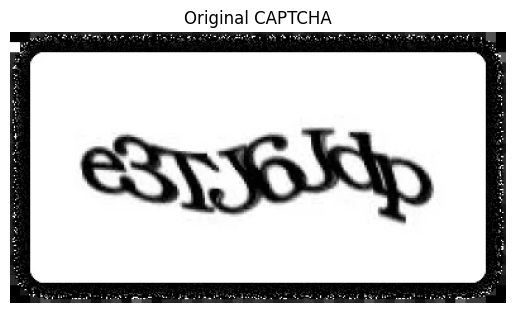

In [17]:
image = cv2.imread('captcha.png')

image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.imshow(image_rgb)
plt.title("Original CAPTCHA")
plt.axis('off')
plt.show()

In [18]:
reader = easyocr.Reader(['en'])

result_before = reader.readtext(image)

print("OCR Sebelum Preprocessing:")

for r in result_before:
    print(r[1])

OCR Sebelum Preprocessing:
e8xSp


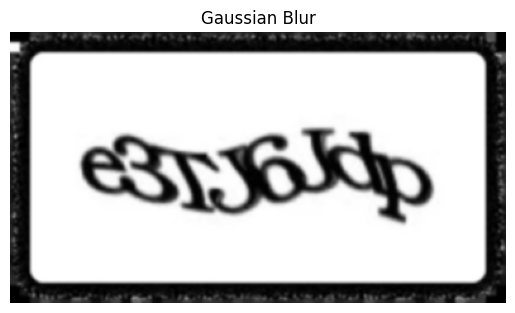

In [19]:
blur = cv2.GaussianBlur(image, (5,5), 0)

plt.imshow(cv2.cvtColor(blur, cv2.COLOR_BGR2RGB))
plt.title("Gaussian Blur")
plt.axis('off')
plt.show()

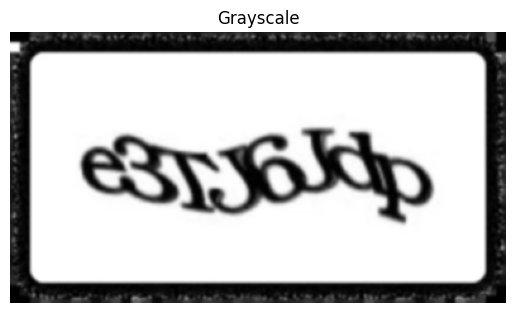

In [20]:
gray = cv2.cvtColor(blur, cv2.COLOR_BGR2GRAY)

plt.imshow(gray, cmap='gray')
plt.title("Grayscale")
plt.axis('off')
plt.show()

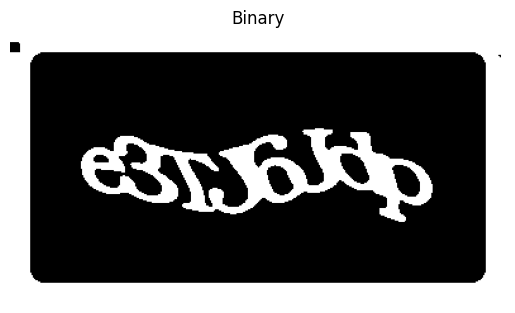

In [21]:
_, binary = cv2.threshold(
    gray,
    0,
    255,
    cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
)

plt.imshow(binary, cmap='gray')
plt.title("Binary")
plt.axis('off')
plt.show()

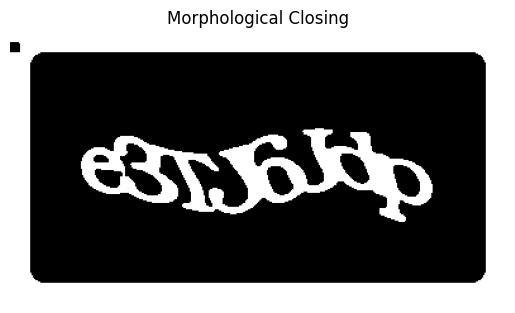

In [22]:
kernel = np.ones((3,3), np.uint8)

closing = cv2.morphologyEx(
    binary,
    cv2.MORPH_CLOSE,
    kernel
)

plt.imshow(closing, cmap='gray')
plt.title("Morphological Closing")
plt.axis('off')
plt.show()

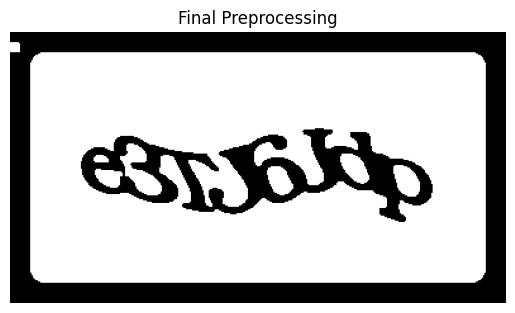

In [23]:
processed = 255 - closing

plt.imshow(processed, cmap='gray')
plt.title("Final Preprocessing")
plt.axis('off')
plt.show()

In [24]:
result_after = reader.readtext(processed)

print("OCR Setelah Preprocessing:")

for r in result_after:
    print(r[1])

OCR Setelah Preprocessing:
e8Jdp


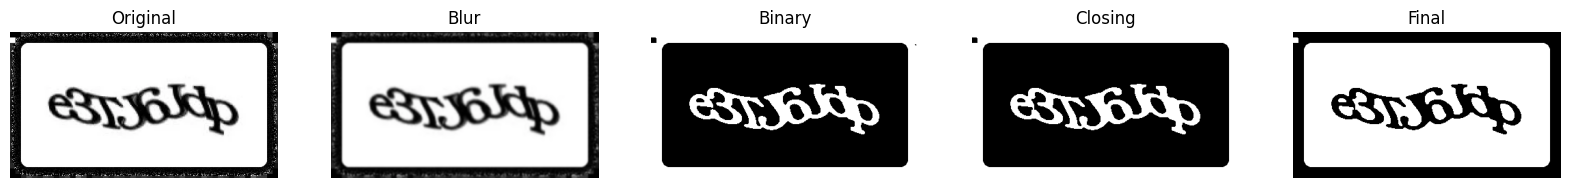

In [25]:
fig, ax = plt.subplots(1,5, figsize=(20,5))

ax[0].imshow(image_rgb)
ax[0].set_title("Original")
ax[0].axis('off')

ax[1].imshow(cv2.cvtColor(blur, cv2.COLOR_BGR2RGB))
ax[1].set_title("Blur")
ax[1].axis('off')

ax[2].imshow(binary, cmap='gray')
ax[2].set_title("Binary")
ax[2].axis('off')

ax[3].imshow(closing, cmap='gray')
ax[3].set_title("Closing")
ax[3].axis('off')

ax[4].imshow(processed, cmap='gray')
ax[4].set_title("Final")
ax[4].axis('off')

plt.show()